In [10]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow


def block_matching(img_l, img_r, window_size, mode='SAD', max_disparity=64):
    h, w = img_l.shape
    disparity_map = np.zeros((h, w), dtype=np.float32)
    half_w = window_size // 2

    # Pad images to handle boundaries
    img_l_pad = np.pad(img_l, half_w, mode='constant')
    img_r_pad = np.pad(img_r, half_w, mode='constant')

    for y in range(half_w, h + half_w):
        for x in range(half_w, w + half_w):
            best_cost = float('inf')
            best_d = 0

            # Extract window from left image
            window_l = img_l_pad[y-half_w : y+half_w+1, x-half_w : x+half_w+1]

            # Search along the scanline in the right image
            for d in range(max_disparity):
                if x - d < half_w: break

                window_r = img_r_pad[y-half_w : y+half_w+1, (x-d)-half_w : (x-d)+half_w+1]

                if mode == 'SAD':
                    cost = np.sum(np.abs(window_l - window_r))
                else: # SSD
                    cost = np.sum((window_l - window_r)**2)

                if cost < best_cost:
                    best_cost = cost
                    best_d = d

            disparity_map[y-half_w, x-half_w] = best_d

    return disparity_map

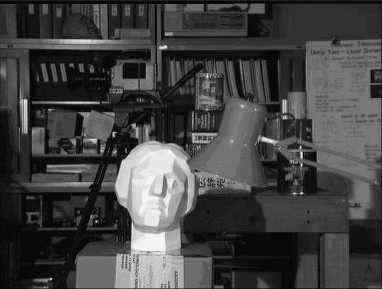

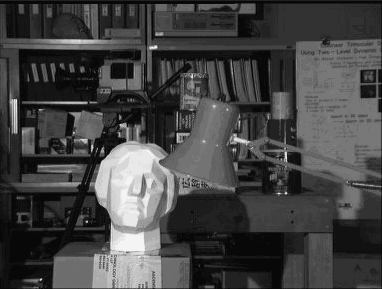

Processing: Window Size 1, Metric SAD...
Processing: Window Size 1, Metric SSD...
Processing: Window Size 5, Metric SAD...
Processing: Window Size 5, Metric SSD...
Processing: Window Size 9, Metric SAD...
Processing: Window Size 9, Metric SSD...


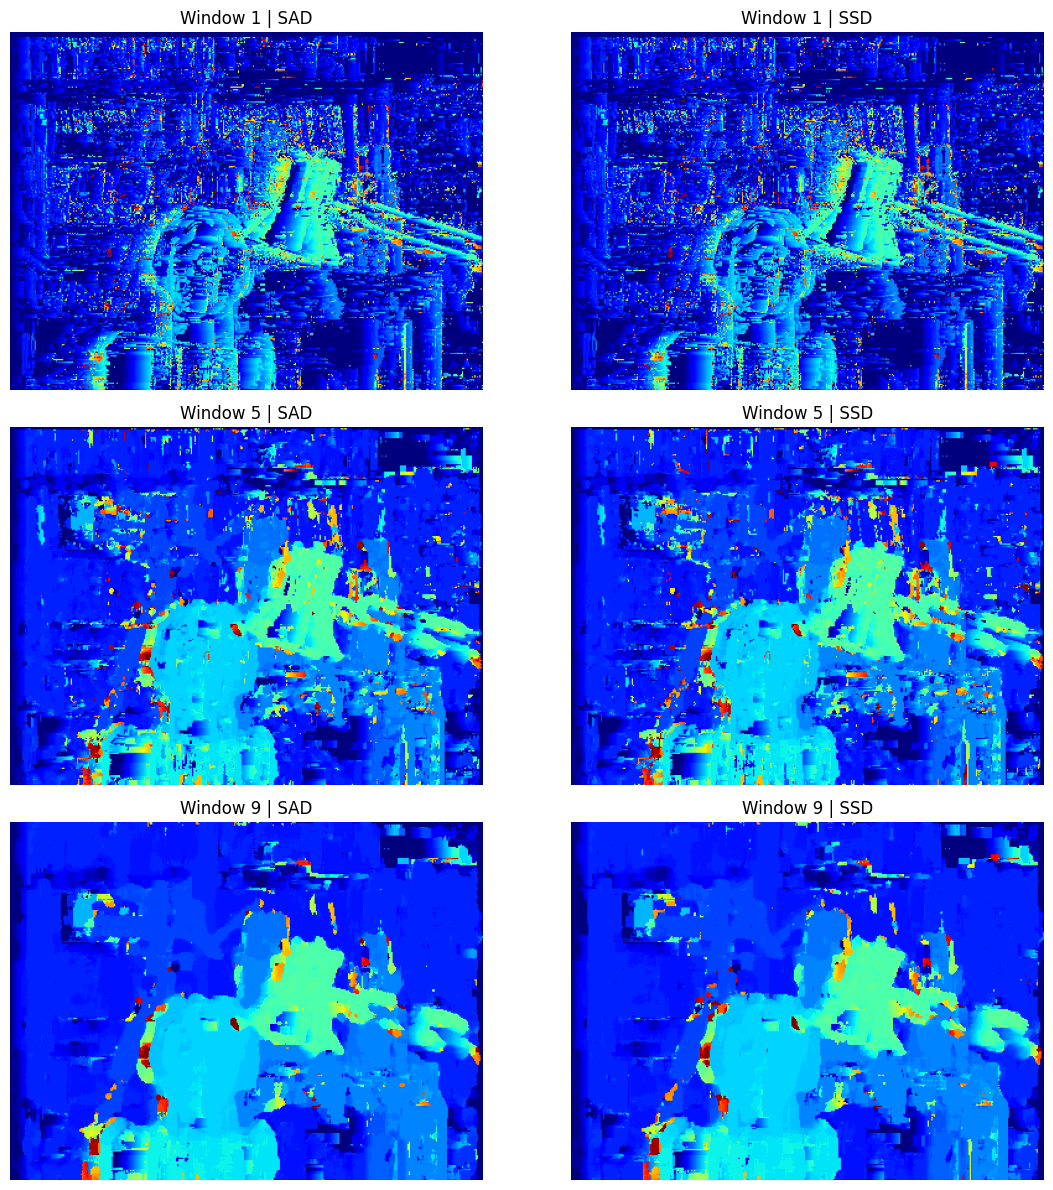

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

def main():
    
    img_l = cv2.imread('/content/drive/MyDrive/CV/Assignment3/l1.png', 0).astype(np.float32)
    img_r = cv2.imread('/content/drive/MyDrive/CV/Assignment3/r1.png', 0).astype(np.float32)
    cv2_imshow(img_l)
    cv2_imshow(img_r)

    if img_l is None or img_r is None:
        print("Error: Could not find 'left.png' or 'right.png'. Please check filenames.")
        return

    
    window_sizes = [1, 5, 9]
    metrics = ['SAD', 'SSD']

    plt.figure(figsize=(12, 12))
    plot_idx = 1

    for w in window_sizes:
        for metric in metrics:
            print(f"Processing: Window Size {w}, Metric {metric}...")
            # Calling the block_matching function provided earlier
            disparity = block_matching(img_l, img_r, window_size=w, mode=metric)

            plt.subplot(3, 2, plot_idx)
            plt.imshow(disparity, cmap='jet')
            plt.title(f"Window {w} | {metric}")
            plt.axis('off')
            plot_idx += 1

    plt.tight_layout()
    plt.show()



if __name__ == "__main__":
    main()

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
